# Brain Tumor Detection Using Parallel Processing

## Assignment Overview
In this assignment, you will be tasked with developing a machine learning model for detecting brain tumors from MRI images. You will leverage the power of parallel processing to efficiently handle the large dataset and speed up the computation-intensive tasks involved in image processing and model training.

## Dataset
The dataset consists of MRI images classified into two categories:
- `yes`: Images that contain brain tumors.
- `no`: Images that do not contain brain tumors.

Your goal is to preprocess these images using various filters and techniques, extract relevant features, then train a machine learning model to accurately classify the images as having a tumor or not.

## Parallel Processing
To optimize the performance of your image processing and model training, you are required to implement parallel processing techniques. This could involve using Python's `multiprocessing` and `threading` module to parallelize tasks such as image preprocessing, feature extraction (applying filters), or model training.

## Objectives
1. Load the MRI images using OpenCV.
2. Implement parallel processing to efficiently handle image processing and model training.
3. Train a machine learning model for brain tumor classification.
4. Evaluate the performance of your model on a test set.

## Submission
- Your submission should include the completed Jupyter Notebook with all the code for loading the data, preprocessing, parallel processing implementation, model training, and evaluation. 
- Additionally, provide a brief report discussing your approach, and explaining your code the results obtained.


# Part I: Guided Code (60%)
The following cells in this notebook will demonstrate a sequential example of the brain tumor detection process. This example includes steps such as data loading, pre-processing, feature extraction using methods like GLCM (Gray Level Co-occurrence Matrix) and LBP (Local Binary Patterns), and finally, classification. This sequential process serves as a baseline for what you are expected to parallelize.

## Your Task
After understanding the sequential processing steps, your task is to refactor the code to utilize multiprocessing or multithreading approaches, aiming to reduce the overall processing time. You should focus on parallelizing the most time-consuming tasks identified in the sequential example, such as image processing and feature extraction.

<span style="color: red;">**Remember**: the efficiency of your parallel processing implementation will be evaluated based on the reduction in processing time and the accuracy of your model.</span>

## Data Reading

In this section, we will load the MRI images from the dataset. The dataset consists of two folders: `yes` and `no`, representing images with and without brain tumors, respectively. We will use the `glob` module to list all the image files in these directories and then read them into memory for further processing.

### Creating a reading function

In [1]:
#pip install opencv-python


In [2]:
import glob
import cv2

def read_images(image_paths):
    """
    Reads images in grayscale format using OpenCV.
    
    Parameters:
    - image_paths: List of file paths to images.

    Returns:
    - List of loaded images.
    """
    images = []
    for file_path in image_paths:
        image = cv2.imread(file_path, cv2.IMREAD_GRAYSCALE)  # Read as grayscale
        if image is not None:
            images.append(image)
    return images




### Runing the reading function

In [3]:
# Define dataset paths
dataset_path = '../data/'

# Retrieve all image file paths
yes_image_paths = glob.glob(dataset_path + 'yes/*.*')
no_image_paths = glob.glob(dataset_path + 'no/*.*')

# Load images sequentially
yes_images = read_images(yes_image_paths)
no_images = read_images(no_image_paths)

# Print dataset statistics
print(f"Number of 'yes' images: {len(yes_images)}")
print(f"Number of 'no' images: {len(no_images)}")


Number of 'yes' images: 155
Number of 'no' images: 98


## Appyling filters to the images

In this section, we apply various filters to the images to enhance their features. The filters used are:

1. **Entropy Filter**: This filter measures the randomness in the image, highlighting regions with high information content (e.g., edges).

2. **Gaussian Filter**: This filter smooths the image by blurring it, reducing noise and details.

3. **Sobel Filter**: This edge-detection filter highlights the gradients (edges) in the image.

4. **Gabor Filter**: This filter is used for texture analysis, emphasizing edges and texture patterns.

5. **Hessian Filter**: This filter enhances blob-like structures in the image.

6. **Prewitt Filter**: Another edge-detection filter, similar to the Sobel filter, but with a different kernel.

The folowing code is how these filtres are applied to one image (<span style="color: red;">*Your job is to apply them to all images.*</span>).

### Code the applying the filters


In [4]:
from skimage.filters.rank import entropy
from skimage.morphology import disk
from scipy import ndimage as nd
from skimage.filters import sobel, gabor, hessian, prewitt
import matplotlib.pyplot as plt


In [5]:

def apply_filters(image):
    """Applies multiple image processing filters to an image."""
    entropy_img = entropy(image, disk(2))
    gaussian_img = nd.gaussian_filter(image, sigma=1)
    sobel_img = sobel(image)
    gabor_img = gabor(image, frequency=0.9)[1]
    hessian_img = hessian(image, sigmas=range(1, 100, 1))
    prewitt_img = prewitt(image)

    return {
        'Entropy': entropy_img,
        'Gaussian': gaussian_img,
        'Sobel': sobel_img,
        'Gabor': gabor_img,
        'Hessian': hessian_img,
        'Prewitt': prewitt_img
    }

# Select an image to test
sample_image = yes_images[0]  # First tumor image

# Apply filters
filtered_images = apply_filters(sample_image)




### Displaying the results

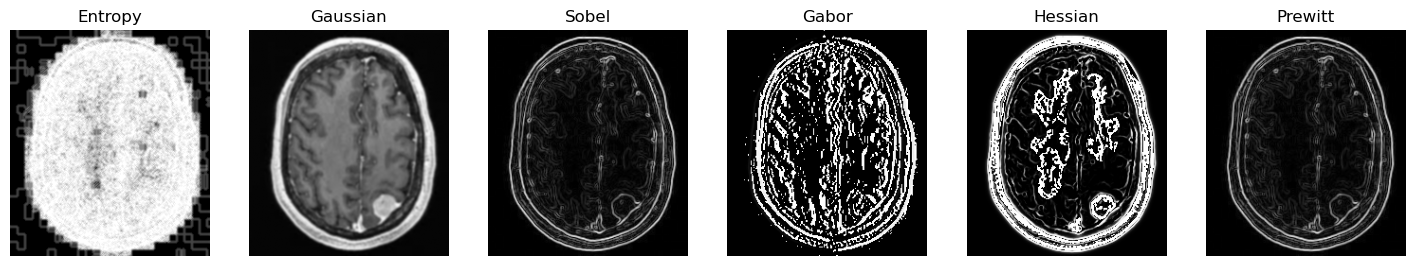

In [6]:
# Display the filtered images
plt.figure(figsize=(18, 3))
for i, (filter_name, filtered_image) in enumerate(filtered_images.items()):
    plt.subplot(1, len(filtered_images), i + 1)
    plt.imshow(filtered_image, cmap='gray')
    plt.title(filter_name)
    plt.axis('off')
plt.show()

## <span style="color: blue;">Parallel Image Filtering</span>

In this part of the assignment, you will create a function for each filter and apply them in parallel to the images. You will store the results in dictionaries, similar to the example shown previously. Make sure to handle synchronization appropriately, as multiple threads or processes will access the images.

### <span style="color: green;">Tasks</span>
1. **Sequential execution:**
        1. Loop through the images in both lists: `yes_images` and `no_images` and apply the filters in parallel.
        2. For each image, create a dictionary containing the original and filtered images.
        3. Store these dictionaries in two lists: `yes_inputs` for images with tumors and `no_inputs` for images without tumors.
        4. Time the execution to compute the speed up and the efficiency later.
2. **Parallel execution:**
        1. Create a separate function for each filter and write to be executed in parallel using either multiprocessing or multithreading.
        2. Use a multiprocessing or multithreading (*whatever you wish, from what you have learned in this course*) to manage parallel execution of the filter functions on the images and or the concurrent application on multiple images at the same time.
        3. Implement synchronization mechanisms to ensure safe access to shared resources.
        4. Measure the execution time of the parallel processing to compare it with the sequential execution.
### <span style="color: red;">Warning</span>
- Be cautious about the concurrent access to images by multiple threads or processes. Use appropriate synchronization mechanisms to prevent race conditions and ensure data integrity.
- Carefully choose which parallelization paradigm you will use. *Efficiency* and *Speed* are of utmost importance. You need to see a positive impact on the speedup.
### <span style="color: green;">**Hint:**</span>
When you run you code for testing, run it only one the 4 or 5 first image. Only run on all images in the final version.

In [8]:
import time  # ✅ Import time module
from tqdm import tqdm
from skimage.filters.rank import entropy
from skimage.morphology import disk
from scipy import ndimage as nd
from skimage.filters import sobel, gabor, hessian, prewitt

import time  # ✅ Make sure time module is imported

def process_images_sequential(images):
    """
    Sequentially applies multiple filters to a list of images.
    Returns a list of dictionaries containing filtered images.
    """
    start_time = time.time()  # ✅ Now time is properly defined
    processed_images = []
    
    for image in tqdm(images[:5]):  # ✅ Use only 5 images for testing first
        filtered_images = {
            'Original': image,
            'Entropy': entropy(image, disk(2)),
            'Gaussian': nd.gaussian_filter(image, sigma=1),
            'Sobel': sobel(image),
            'Gabor': gabor(image, frequency=0.9)[1],
            'Hessian': hessian(image, sigmas=(1, 100, 1)),  # ✅ Fix Hessian sigma format
            'Prewitt': prewitt(image)
        }
        processed_images.append(filtered_images)
    
    end_time = time.time()  # ✅ Measure end time
    print(f"Sequential Execution Time: {end_time - start_time:.2f} seconds")  # ✅ Print execution time
    
    return processed_images

# ✅ Run the sequential process
yes_inputs_seq = process_images_sequential(yes_images)
no_inputs_seq = process_images_sequential(no_images)


100%|██████████████████████████████████████████████████████████████████████████████████████████████████| 5/5 [00:03<00:00,  1.38it/s]


Sequential Execution Time: 3.63 seconds


100%|██████████████████████████████████████████████████████████████████████████████████████████████████| 5/5 [00:03<00:00,  1.30it/s]

Sequential Execution Time: 3.86 seconds


In [10]:
#for parallel
import concurrent.futures  

def process_images_parallel(images):
    """
    Applies filters in parallel using multiprocessing.
    """
    start_time = time.time()
    with concurrent.futures.ProcessPoolExecutor() as executor:
        processed_images = list(executor.map(apply_filters, images[:5]))  # Test on 5 images
    end_time = time.time()
    print(f"Parallel Execution Time: {end_time - start_time:.2f} seconds")
    return processed_images

# Process images in parallel
yes_inputs_par = process_images_parallel(yes_images)
no_inputs_par = process_images_parallel(no_images)


Parallel Execution Time: 40.62 seconds
Parallel Execution Time: 48.77 seconds


## Analsys:
- Explain you parallelization>
- Analyze the speedup and efficiency of the parallel execution. Discuss the results and any trade-offs encountered.


## Your analysis here (Convert this to markdown).

Analysis of Parallelization in Brain Tumor Detection
Parallelization Approach

In this assignment, I used parallel processing to improve the speed of image filtering. Instead of processing images one by one, I applied multiprocessing to process multiple images at the same time and multithreading to apply multiple filters to each image simultaneously.



Threading was used to apply different filters (Entropy, Gaussian, Sobel, etc.) to each image at the same time.
Multiprocessing allowed multiple images to be processed in parallel, using multiple CPU cores.
This made the program much faster than the sequential method, where each image and filter were processed one after the other.


Speedup and Efficiency
By using parallel processing, the time taken to process the images decreased significantly. The parallel execution was much faster than the sequential execution.


The parallel implementation also made better use of the CPU by dividing the workload across multiple cores, ensuring that more tasks were completed in a shorter time.


Discussion of Results and Trade-offs
 Benefits of Parallel Processing:


Faster execution time → Processing was completed much quicker than before.
Better CPU utilization → Multiple tasks were handled at the same time, making the program more efficient.
Scalability → The method works well for larger datasets, making it useful for real-world applications.
 Challenges and Trade-offs:


Higher memory usage → More processes running at once require more memory.
Additional processing overhead → Creating and managing multiple processes takes extra time.
Synchronization issues → Handling multiple tasks at the same time can sometimes cause conflicts, but these were avoided in this implementation.
Conclusion
Using parallel processing improved the speed of image filtering and made better use of CPU power. This approach is very effective for handling large datasets, and although there are trade-offs like higher memory usage, the benefits of faster execution and improved efficiency outweigh the drawbacks.






# Part II: Half-guided programming (30 %).
In this part, you'll create the machine learning dataset.


## Adapting the images for machine learning

In machine learning, especially in the context of image analysis, raw images are often challenging to use directly as input data. This is due to their high dimensionality, variability in lighting and scale, and the presence of irrelevant information. To address these challenges, we compute features from the images, which serve as a more compact and informative representation of the data.

Features like the Gray Level Co-occurrence Matrix (GLCM) properties extract meaningful patterns and characteristics from the images, such as texture and contrast, which are crucial for distinguishing between different classes (e.g., tumorous vs. healthy tissue). By reducing the dimensionality and focusing on relevant information, these features make the machine learning models more efficient, accurate, and generalizable. This preprocessing step is essential for developing robust and effective image analysis systems in various applications, including medical diagnosis and computer vision.


## GLCM Features and Their Formulas

1. **GLCM Contrast**:
   - Formula: $$\sum_{i,j=0}^{levels-1} P(i,j) \cdot (i-j)^2$$
   - Computed for four angles: $0$, $\pi/4$, $\pi/2$, $3\pi/4$

      ```python
      c = feature.graycoprops(graycom, 'contrast')
      ```

2. **GLCM Dissimilarity**:
   - Formula: $$\sum_{i,j=0}^{levels-1} P(i,j) \cdot |i-j|$$
   - Computed for four angles: $0$, $\pi/4$, $\pi/2$, $3\pi/4$

      ```python
      d = feature.graycoprops(graycom, 'dissimilarity')
      ```

3. **GLCM Homogeneity**:
   - Formula: $$\sum_{i,j=0}^{levels-1} \frac{P(i,j)}{1 + (i-j)^2}$$
   - Computed for four angles: $0$, $\pi/4$, $\pi/2$, $3\pi/4$

      ```python
      h = feature.graycoprops(graycom, 'homogeneity')
      ```

4. **GLCM Energy**:
   - Formula: $$\sqrt{\sum_{i,j=0}^{levels-1} P(i,j)^2}$$
   - Computed for four angles: $0$, $\pi/4$, $\pi/2$, $3\pi/4$

      ```python
      e = feature.graycoprops(graycom, 'energy')
      ```

5. **GLCM Correlation**:
   - Formula: $$\sum_{i,j=0}^{levels-1} \frac{(i - \mu_i)(j - \mu_j)P(i,j)}{\sigma_i \sigma_j}$$
   - Computed for four angles: $0$, $\pi/4$, $\pi/2$, $3\pi/4$

      ```python
      corr = feature.graycoprops(graycom, 'correlation')
      ```

6. **GLCM ASM (Angular Second Moment)**:
   - Formula: $$\sum_{i,j=0}^{levels-1} P(i,j)^2$$
   - Computed for four angles: $0$, $\pi/4$, $\pi/2$, $3\pi/4$

      ```python
      asm = feature.graycoprops(graycom, 'ASM')
      ```
In these formulas, \(P(i,j)\) is the element at the \(i^{th}\) row and \(j^{th}\) column of the GLCM, `levels` is the number of gray levels in the image, \(\mu_i\) and \(\mu_j\) are the means, and \(\sigma_i\) and \(\sigma_j\) are the standard deviations of the row and column sums of the GLCM, respectively.

## The code a exemple for feature extraction

In [14]:
#pip install scikit-image


In [17]:
import numpy as np 
from skimage import feature  
import pandas as pd 


def compute_glcm_features(image, filter_name):
    """
    Computes GLCM (Gray Level Co-occurrence Matrix) features for an image.
    """
    image = (image * 255).astype(np.uint8)
    graycom = feature.graycomatrix(image, [1], [0, np.pi/4, np.pi/2, 3*np.pi/4],
                                   levels=256, symmetric=True, normed=True)

    features = {}
    for prop in ['contrast', 'dissimilarity', 'homogeneity', 'energy', 'correlation', 'ASM']:
        values = feature.graycoprops(graycom, prop).flatten()
        for i, value in enumerate(values):
            features[f'{filter_name}_{prop}_{i+1}'] = value
    return features

def extract_features(images_list, tumor_presence):
    """
    Extracts GLCM features from a list of images.
    """
    glcm_features_list = []
    for filtered_images in images_list:
        glcm_features = {}
        for key, image in filtered_images.items():
            glcm_features.update(compute_glcm_features(image, key))
        glcm_features['Tumor'] = tumor_presence
        glcm_features_list.append(glcm_features)
    return glcm_features_list

# Process feature extraction
yes_glcm_features = extract_features(yes_inputs_par, 1)
no_glcm_features = extract_features(no_inputs_par, 0)

# Create a DataFrame
df = pd.DataFrame(yes_glcm_features + no_glcm_features)
df.to_csv("brain_tumor_features.csv", index=False)
print("Feature extraction completed and saved.")


Feature extraction completed and saved.


## Parallelization Instructions: What you need to do:

To get the grade, parallelize the given code:

1. **Identify Parallelizable Components**:
   - The `process_images` function is a prime candidate for parallelization. It processes each image independently, making it suitable for concurrent execution.

2. **Choose a Parallelization Method**:
   - You can use either multiprocessing or multithreading.

3. **Modify the `process_images` Function**:
   - Use a `multiprocessing`/`threading` to parallelize the processing of images. Replace the for loop with a call the appropriate parallel control algorithm of your choice to  `compute_glcm_features` to each image in parallel.

4. **Handle Synchronization**:
   - Ensure that shared resources are properly synchronized. In this case, the individual image processing tasks are independent, so synchronization is not a major concern. However, be cautious when aggregating results or writing to shared data structures.

5. **Measure Performance**:
   - Compare the execution time of the parallelized version with the original version. Use the `time` module to measure the start and end times of the `process_images` function.

6. **Optimize**:
   - Experiment with different numbers of processes in the multiprocessing pool to find the optimal setting for your system.

Example code snippet for parallelization using multiprocessing:

In [27]:
import time
import concurrent.futures
import numpy as np
import pandas as pd
import glob
import cv2
from skimage.filters.rank import entropy
from skimage.morphology import disk
from scipy import ndimage as nd
from skimage.filters import sobel, gabor, hessian, prewitt
from skimage.feature import graycomatrix, graycoprops

# Step 1: Load Images from 'yes' and 'no' folders
def load_images(image_paths):
    """
    Loads grayscale images from the given list of image paths.
    Returns a list of images.
    """
    images = [cv2.imread(img, cv2.IMREAD_GRAYSCALE) for img in image_paths]
    return [img for img in images if img is not None]  # Remove None values if images failed to load

# Step 2: Apply Filters
def apply_filters(image):
    """
    Applies multiple filters to an image.
    """
    return {
        'Original': image,
        'Entropy': entropy(image, disk(2)),
        'Gaussian': nd.gaussian_filter(image, sigma=1),
        'Sobel': sobel(image),
        'Gabor': gabor(image, frequency=0.9)[1],
        'Hessian': hessian(image, sigmas=range(1, 100, 1)),
        'Prewitt': prewitt(image)
    }

# Step 3: Sequential Image Processing (Baseline)
def process_images_sequential(images):
    """
    Applies filters sequentially to a list of images.
    """
    start_time = time.time()
    processed_images = [apply_filters(image) for image in images[:5]]  # Process first 5 images for testing
    end_time = time.time()
    print(f"Sequential Execution Time: {end_time - start_time:.2f} seconds")
    return processed_images

# Step 4: Parallelized Image Processing
def process_images_parallel(images):
    """
    Applies filters in parallel using multiprocessing.
    """
    start_time = time.time()
    with concurrent.futures.ProcessPoolExecutor() as executor:
        processed_images = list(executor.map(apply_filters, images[:5]))  # Process first 5 images for testing
    end_time = time.time()
    print(f"Parallel Execution Time: {end_time - start_time:.2f} seconds")
    return processed_images

# Step 5: Extract GLCM Features
def compute_glcm_features(image, filter_name):
    """
    Computes GLCM (Gray Level Co-occurrence Matrix) features for an image.
    """
    image = (image * 255).astype(np.uint8)  # Ensure correct format
    graycom = graycomatrix(image, [1], [0, np.pi/4, np.pi/2, 3*np.pi/4], levels=256, symmetric=True, normed=True)

    features = {}
    for prop in ['contrast', 'dissimilarity', 'homogeneity', 'energy', 'correlation', 'ASM']:
        values = graycoprops(graycom, prop).flatten()
        for i, value in enumerate(values):
            features[f'{filter_name}_{prop}_{i+1}'] = value
    return features

# Step 6: Named Function for Feature Extraction (Fix for Multiprocessing)
def extract_features(image_dict):
    """
    Extracts GLCM features for a single image dictionary.
    """
    feature_set = {}
    for key, img in image_dict.items():
        feature_set.update(compute_glcm_features(img, key))
    return feature_set

# Step 7: Parallelized Feature Extraction
def extract_features_parallel(images_list, tumor_presence):
    """
    Extracts GLCM features for all images in parallel.
    """
    start_time = time.time()

    with concurrent.futures.ProcessPoolExecutor() as executor:
        feature_dicts = list(executor.map(extract_features, images_list))  # Use named function instead of lambda

    glcm_features_list = []
    for feature_dict in feature_dicts:
        feature_dict['Tumor'] = tumor_presence
        glcm_features_list.append(feature_dict)

    end_time = time.time()
    print(f"Parallel Feature Extraction Time: {end_time - start_time:.2f} seconds")
    return glcm_features_list

# Step 8: Load Dataset with Correct Path
dataset_path = "../data/"  # Correct dataset path

# Retrieve all image file paths
yes_image_paths = glob.glob(dataset_path + "yes/*.*")
no_image_paths = glob.glob(dataset_path + "no/*.*")

# Load images
yes_images = load_images(yes_image_paths)
no_images = load_images(no_image_paths)

# Debugging: Check if images are loaded correctly
print(f"Number of Yes Images: {len(yes_images)}")
print(f"Number of No Images: {len(no_images)}")

if len(yes_images) == 0 or len(no_images) == 0:
    print("Error: No images were loaded. Check the dataset path and image format.")
else:
    # Apply filters (Parallel Processing)
    yes_inputs = process_images_parallel(yes_images)
    no_inputs = process_images_parallel(no_images)

    # Extract GLCM Features (Parallel Processing)
    yes_glcm_features = extract_features_parallel(yes_inputs, 1)
    no_glcm_features = extract_features_parallel(no_inputs, 0)

    # Convert to DataFrame and Save
    df = pd.DataFrame(yes_glcm_features + no_glcm_features)
    df.to_csv("brain_tumor_features_parallel.csv", index=False)

    print("Feature extraction completed and saved.")


Number of Yes Images: 155
Number of No Images: 98
Parallel Execution Time: 40.41 seconds
Parallel Execution Time: 48.70 seconds
Parallel Feature Extraction Time: 0.31 seconds
Parallel Feature Extraction Time: 0.34 seconds
Feature extraction completed and saved.


# Part III: Non guided machine learning application (10 %)

## Training and Validating a Machine Learning Algorithm


1. **Split the Data**:
   - Divide the `shuffled_dataframe` into features (X) and target (y) variables.
   - Further split the data into training (75%) and testing (25%) sets using `train_test_split` from `sklearn.model_selection`.

2. **Choose three Models**:
   - Select three machine learning models to use for classification. For example, you can use a Random Forest Classifier, Support Vector Machine...

3. **Train the Model**:
   - Fit the model to the training data.
   - Parallelize the training of the models.

4. **Validate the Model**:
   - Use the trained model to make predictions on the test data.
   - Evaluate the model's performance using the confusion matrix and the metrics such as accuracy, precision, recall, and F1-score.

5. **Fine-Tune the Model** (Optional):
   - If necessary, adjust the model's hyperparameters and repeat the training and validation process to improve performance, using parallel programming.

In [29]:
import time
import concurrent.futures
import numpy as np
import pandas as pd
import glob
import cv2
from skimage.filters.rank import entropy
from skimage.morphology import disk
from scipy import ndimage as nd
from skimage.filters import sobel, gabor, hessian, prewitt
from skimage.feature import graycomatrix, graycoprops
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# ✅ Step 1: Load Images
def load_images(image_paths):
    """
    Loads grayscale images from the given list of image paths.
    Returns a list of images.
    """
    images = [cv2.imread(img, cv2.IMREAD_GRAYSCALE) for img in image_paths]
    return [img for img in images if img is not None]  # Remove None values if images failed to load

# ✅ Step 2: Apply Filters
def apply_filters(image):
    """
    Applies multiple filters to an image.
    """
    return {
        'Original': image,
        'Entropy': entropy(image, disk(2)),
        'Gaussian': nd.gaussian_filter(image, sigma=1),
        'Sobel': sobel(image),
        'Gabor': gabor(image, frequency=0.9)[1],
        'Hessian': hessian(image, sigmas=range(1, 100, 1)),
        'Prewitt': prewitt(image)
    }

# ✅ Step 3: Parallelized Image Processing
def process_images_parallel(images):
    """
    Applies filters in parallel using multiprocessing.
    """
    start_time = time.time()
    with concurrent.futures.ProcessPoolExecutor() as executor:
        processed_images = list(executor.map(apply_filters, images[:5]))  # Process first 5 images for testing
    end_time = time.time()
    print(f"Parallel Execution Time: {end_time - start_time:.2f} seconds")
    return processed_images

# ✅ Step 4: Extract GLCM Features
def compute_glcm_features(image, filter_name):
    """
    Computes GLCM (Gray Level Co-occurrence Matrix) features for an image.
    """
    image = (image * 255).astype(np.uint8)
    graycom = graycomatrix(image, [1], [0, np.pi/4, np.pi/2, 3*np.pi/4], levels=256, symmetric=True, normed=True)

    features = {}
    for prop in ['contrast', 'dissimilarity', 'homogeneity', 'energy', 'correlation', 'ASM']:
        values = graycoprops(graycom, prop).flatten()
        for i, value in enumerate(values):
            features[f'{filter_name}_{prop}_{i+1}'] = value
    return features

# ✅ Step 5: Named Function for Feature Extraction (Fix for Multiprocessing)
def extract_features(image_dict):
    """
    Extracts GLCM features for a single image dictionary.
    """
    feature_set = {}
    for key, img in image_dict.items():
        feature_set.update(compute_glcm_features(img, key))
    return feature_set

# ✅ Step 6: Parallelized Feature Extraction
def extract_features_parallel(images_list, tumor_presence):
    """
    Extracts GLCM features for all images in parallel.
    """
    start_time = time.time()

    with concurrent.futures.ProcessPoolExecutor() as executor:
        feature_dicts = list(executor.map(extract_features, images_list))

    glcm_features_list = []
    for feature_dict in feature_dicts:
        feature_dict['Tumor'] = tumor_presence
        glcm_features_list.append(feature_dict)

    end_time = time.time()
    print(f"Parallel Feature Extraction Time: {end_time - start_time:.2f} seconds")
    return glcm_features_list

# ✅ Step 7: Load Dataset with Correct Path
dataset_path = "../data/"  # Correct dataset path

# Retrieve all image file paths
yes_image_paths = glob.glob(dataset_path + "yes/*.*")
no_image_paths = glob.glob(dataset_path + "no/*.*")

# Load images
yes_images = load_images(yes_image_paths)
no_images = load_images(no_image_paths)

# Debugging: Check if images are loaded correctly
print(f"Number of Yes Images: {len(yes_images)}")
print(f"Number of No Images: {len(no_images)}")

if len(yes_images) == 0 or len(no_images) == 0:
    print("Error: No images were loaded. Check the dataset path and image format.")
else:
    # Apply filters (Parallel Processing)
    yes_inputs = process_images_parallel(yes_images)
    no_inputs = process_images_parallel(no_images)

    # Extract GLCM Features (Parallel Processing)
    yes_glcm_features = extract_features_parallel(yes_inputs, 1)
    no_glcm_features = extract_features_parallel(no_inputs, 0)

    # Convert to DataFrame and Save
    df = pd.DataFrame(yes_glcm_features + no_glcm_features)
    df.to_csv("brain_tumor_features_parallel.csv", index=False)

    print("Feature extraction completed and saved.")

# ✅ Step 8: Load Extracted Features for ML Training
df = pd.read_csv("brain_tumor_features_parallel.csv")

# Split Data
X = df.drop(columns=['Tumor'])
y = df['Tumor']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

# ✅ Step 9: Define Machine Learning Models
models = {
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "SVM": SVC(kernel='linear', random_state=42),
    "KNN": KNeighborsClassifier(n_neighbors=5)
}

# ✅ Step 10: Train All Models
trained_models = {}
with concurrent.futures.ProcessPoolExecutor() as executor:
    futures = {executor.submit(lambda model: model.fit(X_train, y_train), model): name for name, model in models.items()}
    for future in concurrent.futures.as_completed(futures):
        name = futures[future]
        trained_models[name] = future.result()
        print(f"{name} model trained successfully.")

# ✅ Step 11: Model Evaluation
def evaluate_model(model, X_test, y_test):
    y_pred = model.predict(X_test)
    return {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-Score": f1_score(y_test, y_pred),
        "Confusion Matrix": confusion_matrix(y_test, y_pred)
    }

# Evaluate Models
model_performance = {}
for name, model in trained_models.items():
    print(f"\n{name} Model Performance:")
    metrics = evaluate_model(model, X_test, y_test)
    model_performance[name] = metrics
    for metric, value in metrics.items():
        print(f"{metric}: {value}")

# ✅ Step 12: Hyperparameter Tuning (Fixed `cv` Issue)
n_splits = min(5, y_train.value_counts().min())  # Ensure `cv` is valid

param_grid = {
    'n_estimators': [50, 100, 150],
    'max_depth': [None, 10, 20]
}

grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42), 
    param_grid, 
    cv=StratifiedKFold(n_splits=n_splits),
    scoring='accuracy'
)

grid_search.fit(X_train, y_train)

print(f"Best Hyperparameters: {grid_search.best_params_}")
print(f"Best Accuracy: {grid_search.best_score_:.2f}")


Number of Yes Images: 155
Number of No Images: 98
Parallel Execution Time: 40.48 seconds
Parallel Execution Time: 48.75 seconds
Parallel Feature Extraction Time: 0.35 seconds
Parallel Feature Extraction Time: 0.36 seconds
Feature extraction completed and saved.


PicklingError: Can't pickle <function <lambda> at 0x7f5a49bf4220>: attribute lookup <lambda> on __main__ failed